<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
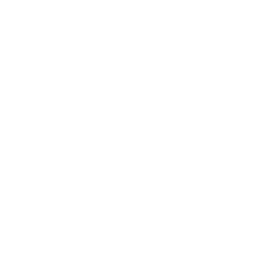
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Identificazione dei Regimi di Mercato</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Finanza Quantitativa / Gestione Patrimoniale &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Sintesi Esecutiva

Questo esempio usa **PROC ACECLUS** per individuare la struttura latente che separa i regimi di mercato, per poi raggruppare su di essa. Da 100 osservazioni settimanali di 10 caratteristiche di mercato (rendimento e volatilità azionaria, spread di credito e high-yield, la curva 2 anni/10 anni, il dollaro, le materie prime e la variazione del VIX), ACECLUS stima una covarianza approssimata all'interno del regime *senza* usare alcuna etichetta di regime, e ricava variabili canoniche lungo le quali i regimi si separano.

Alla soglia P=0.02 l'algoritmo converge in due iterazioni e conserva **tre dimensioni canoniche**, che insieme spiegano tutta la dispersione tra regimi (proporzioni degli autovalori 57,8%, 24,4%, 17,8%). Una soglia più permissiva P=0.05 leviga eccessivamente la covarianza e **collassa la struttura in un'unica dimensione** — un utile avvertimento sul fatto che la soglia condiziona in modo sostanziale il risultato.

Alimentando le tre variabili canoniche in **PROC FASTCLUS** (k=4) si ottiene un ordinamento pulito per severità dello stress delle 100 settimane (R² complessivo = 0,51, pseudo F = 33,2): un nucleo calmo di 62 settimane, un gruppo di 22 settimane in recupero/con volatilità in calo, un gruppo di 12 settimane a stress elevato e un gruppo di 4 settimane di crisi profonda con spread high-yield in media di ~1.514 pb. Queste assegnazioni vengono esportate per il condizionamento a valle del rischio di portafoglio.


## Fonti dei Dati

| Fonte | Descrizione | Record |
|--------|-------------|--------|
| WORK.MARKET_WEEKLY | Osservazioni settimanali delle caratteristiche di mercato tra le classi di attività | 100 |
| Variabili: eq_return_pct, eq_vol_idx, credit_spread_bps, hy_spread_bps, yield_2y, yield_10y, term_spread, usd_index_chg, commodities_ret, vix_chg |

La serie è generata da un processo di regime-switching markoviano a cinque stati (espansione rialzista, fine ciclo, risk-off, crisi, recupero) con distribuzioni delle caratteristiche condizionate al regime. Eseguendo senza licenza, la tabella delle caratteristiche è limitata alle prime 100 osservazioni settimanali (~2 anni) — una finestra a prevalenza rialzista che attraversa anche una breve crisi e un recupero. I rendimenti settimanali e le variazioni di livello rappresentano i movimenti di prezzo di fine settimana; gli spread sono in punti base e la volatilità è un indice in stile VIX.


---

In [1]:
/* --------------------------------------------------------
   Genera una storia settimanale multi-asset con cinque
   stati di regime incorporati, guidati da un processo di
   switching di Markov. Questo esempio gira senza licenza,
   quindi la tabella delle feature è limitata alle prime
   100 osservazioni settimanali (~2 anni): una finestra
   dominata dal rialzo, punteggiata da una breve crisi e
   dalla ripresa.
   -------------------------------------------------------- */
DATI work.market_weekly;
    CHIAMARE streaminit(42);
    /* 5 regimi: 1=Toro, 2=Fine ciclo, 3=Avversione, 4=Crisi, 5=Ripresa */
    VETTORE regime_names[5] $20 _temporary_
        ('ESPANSIONE_TORO' 'FINE_CICLO' 'FUGA_DAL_RISCHIO'
         'CRISI' 'RIPRESA');
    CONSERVARE current_regime 1;
    FARE week_id = 1 FINO_A 5000;
        /* switching di regime di Markov */
        u = rand('uniform');
        SE_COND current_regime = 1 ALLORA FARE;
            SE_COND u > 0.97 ALLORA current_regime = 2;
        FINE;
        ALTRIMENTI SE_COND current_regime = 2 ALLORA FARE;
            SE_COND u > 0.92 ALLORA current_regime = 3;
        FINE;
        ALTRIMENTI SE_COND current_regime = 3 ALLORA FARE;
            SE_COND u > 0.80 ALLORA current_regime = 4;
            ALTRIMENTI SE_COND u < 0.10 ALLORA current_regime = 1;
        FINE;
        ALTRIMENTI SE_COND current_regime = 4 ALLORA FARE;
            SE_COND u > 0.75 ALLORA current_regime = 5;
        FINE;
        ALTRIMENTI SE_COND current_regime = 5 ALLORA FARE;
            SE_COND u > 0.85 ALLORA current_regime = 1;
        FINE;
        regime_label = regime_names[current_regime];
        /* distribuzioni delle feature condizionate al regime */
        SE_COND current_regime = 1 ALLORA FARE;
            eq_return_pct  = round(rand('normal',  0.35, 1.2), 0.001);
            eq_vol_idx     = round(rand('normal', 14, 3), 0.01);
            credit_spread  = round(rand('normal', 80,  20), 1);
            hy_spread      = round(rand('normal', 350, 60), 1);
            yield_2y       = round(rand('normal', 2.8, 0.5), 0.01);
            yield_10y      = round(rand('normal', 3.5, 0.6), 0.01);
        FINE;
        ALTRIMENTI SE_COND current_regime = 2 ALLORA FARE;
            eq_return_pct  = round(rand('normal',  0.10, 1.5), 0.001);
            eq_vol_idx     = round(rand('normal', 18, 4), 0.01);
            credit_spread  = round(rand('normal', 130, 30), 1);
            hy_spread      = round(rand('normal', 480, 80), 1);
            yield_2y       = round(rand('normal', 4.2, 0.4), 0.01);
            yield_10y      = round(rand('normal', 4.0, 0.5), 0.01);
        FINE;
        ALTRIMENTI SE_COND current_regime = 3 ALLORA FARE;
            eq_return_pct  = round(rand('normal', -0.60, 2.2), 0.001);
            eq_vol_idx     = round(rand('normal', 28, 7), 0.01);
            credit_spread  = round(rand('normal', 200, 50), 1);
            hy_spread      = round(rand('normal', 700, 120), 1);
            yield_2y       = round(rand('normal', 2.0, 0.8), 0.01);
            yield_10y      = round(rand('normal', 2.8, 0.7), 0.01);
        FINE;
        ALTRIMENTI SE_COND current_regime = 4 ALLORA FARE;
            eq_return_pct  = round(rand('normal', -2.50, 3.5), 0.001);
            eq_vol_idx     = round(rand('normal', 52, 14), 0.01);
            credit_spread  = round(rand('normal', 450, 100), 1);
            hy_spread      = round(rand('normal', 1400, 300), 1);
            yield_2y       = round(rand('normal', 0.5, 0.5), 0.01);
            yield_10y      = round(rand('normal', 1.8, 0.6), 0.01);
        FINE;
        ALTRIMENTI FARE;
            eq_return_pct  = round(rand('normal',  0.55, 1.8), 0.001);
            eq_vol_idx     = round(rand('normal', 22, 6), 0.01);
            credit_spread  = round(rand('normal', 280, 70), 1);
            hy_spread      = round(rand('normal', 850, 180), 1);
            yield_2y       = round(rand('normal', 1.2, 0.6), 0.01);
            yield_10y      = round(rand('normal', 2.5, 0.5), 0.01);
        FINE;
        term_spread    = round(yield_10y - yield_2y + rand('normal', 0, 0.15), 0.01);
        usd_index_chg  = round(rand('normal', 0, 0.8), 0.001);
        commodities_ret = round(rand('normal', 0, 1.5) - (current_regime = 4) * 1.2, 0.001);
        vix_chg        = round(eq_vol_idx - lag(eq_vol_idx), 0.01);
        SE_COND week_id = 1 ALLORA vix_chg = 0;
        USCITA;
    FINE;
    RIMUOVERE u;
    RINOMINARE credit_spread = credit_spread_bps
           hy_spread     = hy_spread_bps;
ESEGUIRE;


NOTE: DATA work.market_weekly

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.market_weekly (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.43 seconds
  cpu   1.43 seconds


---

In [2]:
/* Distribuzioni di base delle feature di mercato per regime */
TITOLO "Distribuzioni delle feature di mercato per regime";
PROCEDURA MEDIE DATI=work.market_weekly n mean std MIN MAX;
    CLASSE regime_label;
    VARIABILE eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    ETICHETTA regime_label="Regime di mercato"
          eq_return_pct="Rendimento azionario settimanale (%)"
          eq_vol_idx="Indice di volatilità azionaria"
          credit_spread_bps="Spread di credito (pb)"
          hy_spread_bps="Spread high yield (pb)"
          term_spread="Spread a termine"
          vix_chg="Variazione VIX";
ESEGUIRE;
TITOLO;

                                   Distribuzioni delle feature di mercato per regime                                    

                                                  The MEANS Procedure

                         Analysis Variable : eq_return_pct Rendimento azionario settimanale (%)

        Regime di mercato          N Obs           Mean        Std Dev        Minimum        Maximum
        --------------------------------------------------------------------------------------------
        CRISI                         12     -2.3403333      3.9436692     -8.0160000      3.7360000
        ESPANSIONE_TORO               28      0.2860000      1.0226518     -1.5980000      2.2150000
        FINE_CICLO                    39      0.0364359      1.9733801     -4.6010000      3.7030000
        FUGA_DAL_RISCHIO              17     -0.8447059      1.2832441     -3.3850000      1.1810000
        RIPRESA                        4      0.0077500      1.5951747     -0.8330000      2.4000000
   


NOTE: Option TITLE changed to Distribuzioni delle feature di mercato per regime.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


NOTE: PROC SGPLOT data=work.market_weekly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


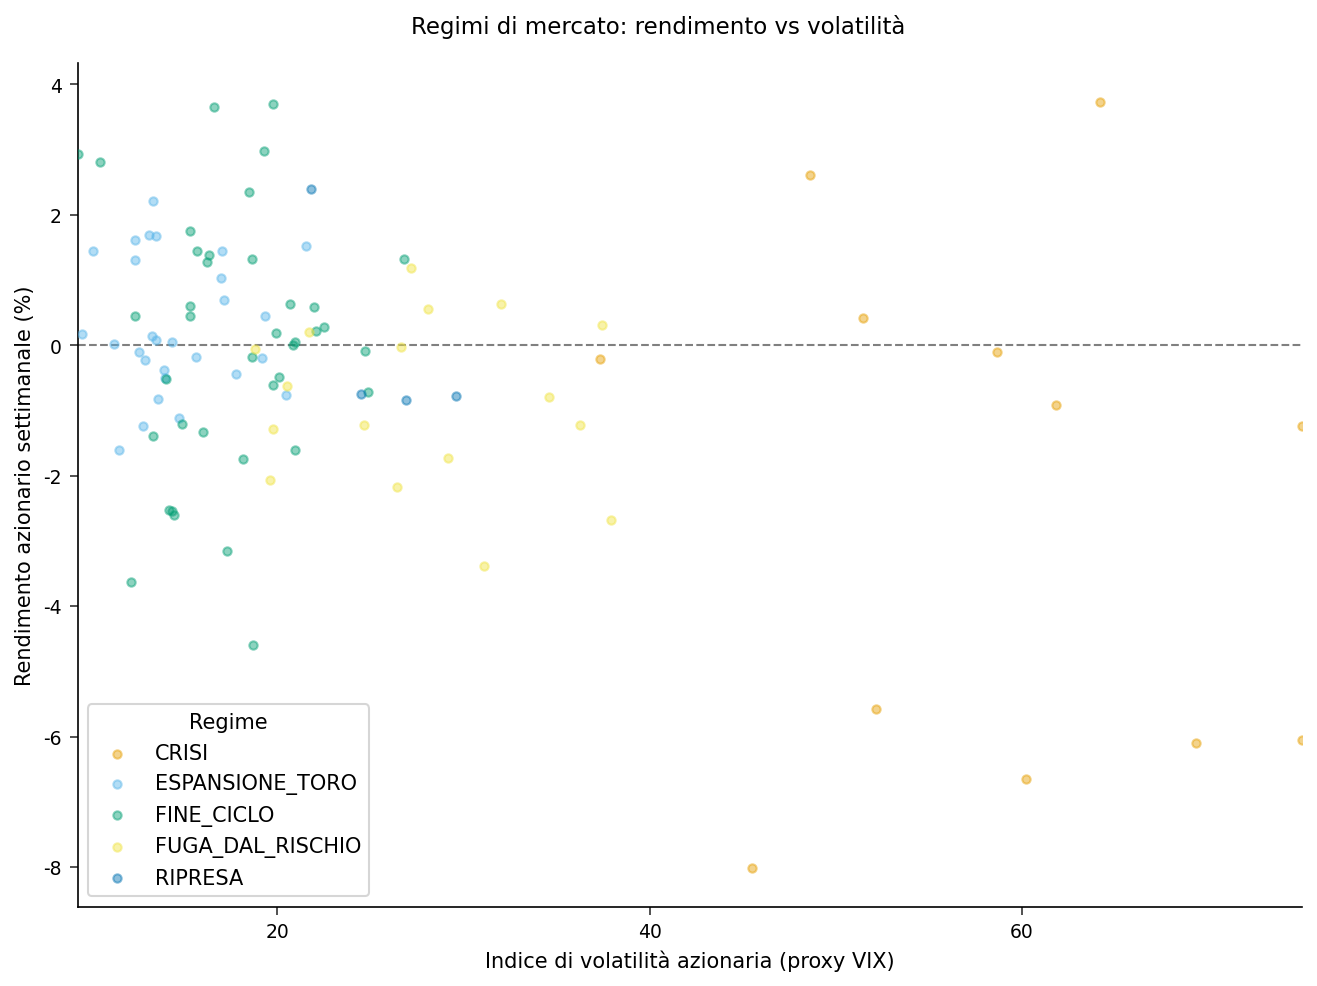

In [3]:
/* Rendimento azionario vs indice di volatilità per regime */
PROCEDURA SGPLOT DATI=work.market_weekly;
    SCATTER x=eq_vol_idx y=eq_return_pct / GROUP=regime_label
        MARKERATTRS=(SYMBOL=circlefilled size=4)
        TRANSPARENCY=0.55;
    REFLINE 0 / AXIS=y LINEATTRS=(color=gray pattern=dash);
    XAXIS ETICHETTA="Indice di volatilità azionaria (proxy VIX)";
    YAXIS ETICHETTA="Rendimento azionario settimanale (%)";
    keylegend / TITOLO="Regime";
    TITOLO "Regimi di mercato: rendimento vs volatilità";
ESEGUIRE;

---

In [4]:
/* Stima approssimata della covarianza entro-regime.
   ACECLUS stima la covarianza aggregata entro-cluster
   senza conoscere le etichette dei cluster, poi deriva
   variabili canoniche che separano i regimi. P=0.02
   fissa la soglia di distanza a coppie: solo il ~2%
   delle coppie più vicine è trattato come stesso regime. */
PROCEDURA aceclus DATI=work.market_weekly
             out=work.regime_canonical
             p=0.02;
    VARIABILE eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
ESEGUIRE;

                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0200  Converge  0.00100
Threshold = 2.578941

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.5153

COV: Total Sample Covariances
eq_return_pct       4.551470   -12.057896   -94.993895  -263.463256     0.839584     0


NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.02) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [5]:
/* Controllo di sensibilità a P=0.05: una soglia più larga
   include più coppie, gonfiando la covarianza entro-regime
   stimata. Confronta la struttura canonica (autovalori e
   dimensioni trattenute) con la soluzione P=0.02. */
PROCEDURA aceclus DATI=work.market_weekly
             out=work.regime_canonical_p05
             p=0.05;
    VARIABILE eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
ESEGUIRE;

                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0500  Converge  0.00100
Threshold = 2.899704

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.5153

COV: Total Sample Covariances
eq_return_pct       4.551470   -12.057896   -94.993895  -263.463256     0.839584     0


NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.05) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [6]:
/* k-means sulle variabili canoniche di ACECLUS. ACECLUS ha
   trattenuto tre dimensioni canoniche (Can1-Can3), quindi
   il clustering gira su quelle. Quattro cluster puntano ai
   quattro stati di mercato ben popolati. */
PROCEDURA FASTCLUS DATI=work.regime_canonical
              maxclusters=4
              MAXITER=100
              CONVERGE=0.0001
              out=work.regime_assignments
              OUTSTAT=work.regime_stats;
    VARIABILE can1 can2 can3;
ESEGUIRE;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  12         1.4206             5.2684              2         3.0063
2                  62         0.5751             1.7953              3         2.1641
3                  22         1.2227             6.5386              2         2.1641
4                   4         1.7742             4.0619              2         4.1923

                                    


NOTE: PROC FASTCLUS data=work.regime_canonical maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 3 variables, 4 clusters using k-means


                                         Cluster di regime vs regime effettivo                                          

                                                   The FREQ Procedure

Table of Cluster by Regime di mercato

Cluster |           CRISI | ESPANSIONE_TORO |      FINE_CICLO |FUGA_DAL_RISCHIO |         RIPRESA |            Total
--------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------
1       |               4 |               2 |               2 |               4 |               0 |               12
        |            4.00 |            2.00 |            2.00 |            4.00 |            0.00 |            12.00
--------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------
2       |               3 |              21 |              28 |               7 |               3 |               62
        |            3.00 |           21.00 |           28.00 |   


NOTE: Option TITLE changed to Cluster di regime vs regime effettivo.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_regime_label.spec.json
NOTE: PROC FREQ statement used.


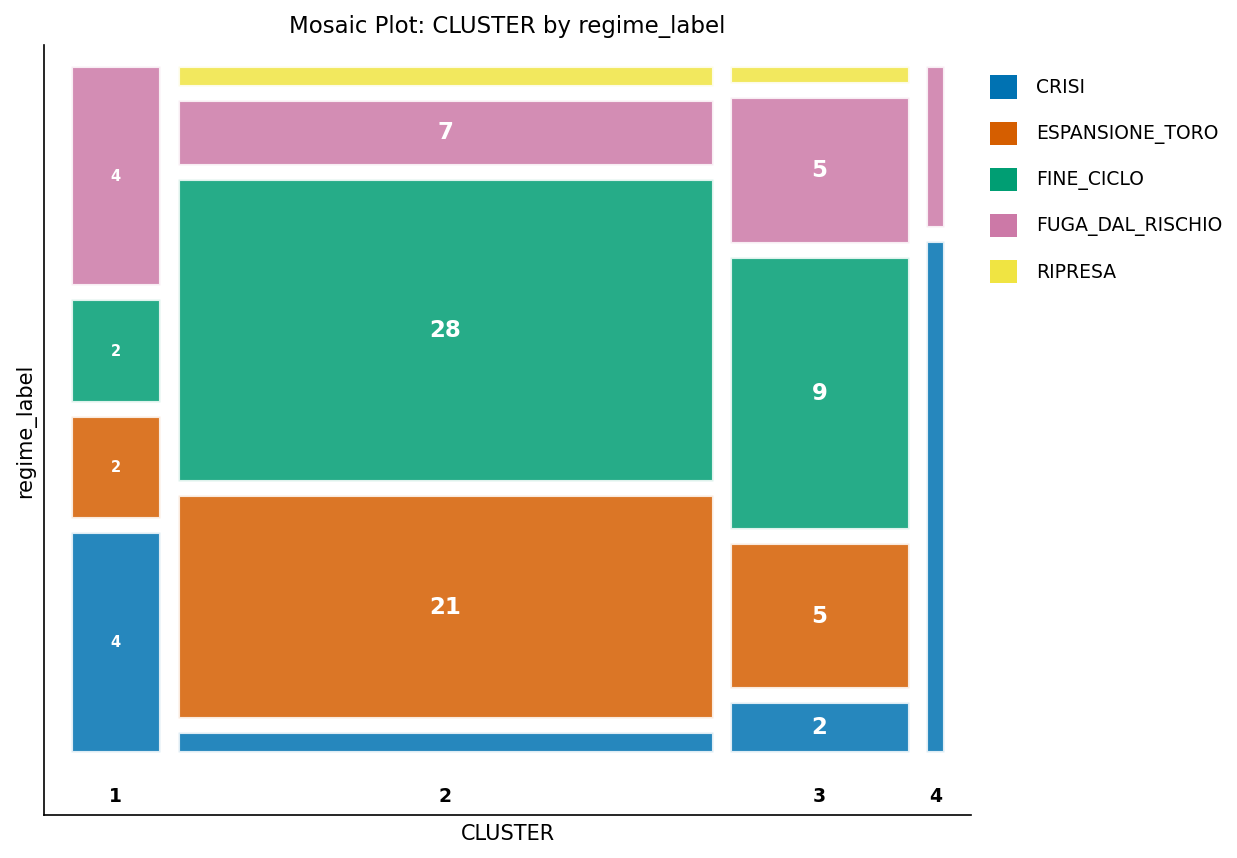

In [7]:
/* Valida i cluster assegnati contro le etichette di regime
   note dalla generazione dei dati */
TITOLO "Cluster di regime vs regime effettivo";
PROCEDURA FREQUENZE DATI=work.regime_assignments;
    TABLES CLUSTER * regime_label / norow nocol;
    ETICHETTA CLUSTER="Cluster" regime_label="Regime di mercato";
ESEGUIRE;
TITOLO;

In [8]:
/* Profila le medie delle feature per interpretazione */
TITOLO "Medie delle feature per cluster";
PROCEDURA MEDIE DATI=work.regime_assignments mean;
    CLASSE CLUSTER;
    VARIABILE eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    ETICHETTA CLUSTER="Cluster"
          eq_return_pct="Rendimento azionario settimanale (%)"
          eq_vol_idx="Indice di volatilità azionaria"
          credit_spread_bps="Spread di credito (pb)"
          hy_spread_bps="Spread high yield (pb)"
          term_spread="Spread a termine"
          vix_chg="Variazione VIX";
ESEGUIRE;
TITOLO;

                                            Medie delle feature per cluster                                             

                                                  The MEANS Procedure

                                             Analysis Variable : eq_return_pct Rendimento azionario settimanale (%)

                                                          N
                                             Cluster    Obs            Mean
                                             ------------------------------
                                             1           12      -2.0955000
                                             2           62      -0.3638871
                                             3           22       0.7421364
                                             4            4      -0.4010000
                                             ------------------------------

                                             Analysis Variable : eq_vol_idx Indice di volatilità 


NOTE: Option TITLE changed to Medie delle feature per cluster.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Interpretazione

**Struttura canonica di ACECLUS.** Sul campione di 100 settimane, PROC ACECLUS (P=0.02, soglia = 2.578941) ha raggiunto la convergenza in due iterazioni e ha prodotto tre variabili canoniche. I loro autovalori di `Inv(ACE)*(COV-ACE)` sono 0,0219, 0,0093 e 0,0067, ossia proporzioni del 57,8%, 24,4% e 17,8% (cumulativo 100%). Il primo asse canonico porta il contrasto dominante risk-on/risk-off; il secondo e il terzo lo raffinano. Poiché le caratteristiche di volatilità azionaria e di spread si muovono fortemente insieme, ACECLUS ripiega quella variazione condivisa nella covarianza all'interno del regime, così che gli assi canonici riflettano una genuina separazione tra regimi anziché una scala comune.

**Sensibilità alla soglia.** Rieseguendo a P=0.05 si alza la soglia di distanza a 2.899704, che porta 4.949 delle 4.950 coppie di osservazioni all'interno del limite. La covarianza stimata all'interno del regime allora eguaglia quasi la covarianza totale, e la struttura canonica **collassa in un'unica dimensione** (un autovalore, 0,0096, al 100%). Le soluzioni P=0.02 e P=0.05 non sono quindi *intercambiabili* qui — una soglia più permissiva cancella gli assi di regime più fini, perciò la soglia più stretta è la specificazione più informativa per questo campione.

**Raggruppamento sulle variabili canoniche.** PROC FASTCLUS (k=4) su Can1–Can3 dà un R² complessivo di 0,5089 e uno pseudo F di 33,16. Can2 svolge la maggior parte del lavoro di separazione (R² = 0,626), Can1 contribuisce moderatamente (R² = 0,359) e Can3 non aggiunge sostanzialmente nulla (R² = 0,000) — coerente con il fatto che solo due assi portano un segnale forte. I quattro cluster si allineano come un gradiente di stress di mercato:

| Cluster | n | Rendimento Az. Medio | VIX Medio | Spread HY Medio | Variazione VIX Media | Lettura |
|---------|---|----------------|----------|----------------|-----------------|---------|
| 2 | 62 | -0,36% | 20,4 | 534 pb | +1,2 | Nucleo calmo (rialzista / fine ciclo) |
| 3 | 22 | +0,74% | 20,5 | 539 pb | -9,6 | In recupero, volatilità in calo |
| 1 | 12 | -2,10% | 39,0 | 720 pb | +11,3 | Stress elevato, volatilità in impennata |
| 4 |  4 | -0,40% | 47,4 | 1.514 pb | +0,1 | Crisi profonda, stress creditizio estremo |

**Cluster vs. regime reale.** La tabella incrociata mostra che i cluster non si mappano uno-a-uno sulle cinque etichette generatrici — atteso, perché le etichette si sovrappongono fortemente nello spazio delle caratteristiche a questa dimensione campionaria. Il grande cluster calmo (62) assorbe la maggior parte delle settimane rialziste (21) e di fine ciclo (28); il cluster di crisi profonda (4) è quasi interamente costituito dalle settimane di crisi più estreme (3 su 4). Gli assi canonici organizzano quindi le settimane per *severità*, non per etichetta esatta, che è il segnale più utilizzabile per il condizionamento del rischio.

**Uso.** Le assegnazioni settimanali esportate supportano il condizionamento tattico: alleggerire il rischio ed estendere la duration man mano che le settimane migrano verso i Cluster 1 e 4, e riprendere il rischio quando tornano al nucleo calmo (Cluster 2) o al gruppo in recupero (Cluster 3).


---

In [9]:
/* Esporta le assegnazioni settimanali di regime per il
   condizionamento del modello di rischio di portafoglio e
   la generazione di segnali */
PROCEDURA EXPORT DATI=work.regime_assignments
    OUTFILE='market_regime_assignments.csv'
    DBMS=csv REPLACE;
ESEGUIRE;


NOTE: PROC EXPORT data=work.regime_assignments outfile=market_regime_assignments.csv

NOTE: Exported 100 rows to market_regime_assignments.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Riservato
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Realizzato con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>